In [57]:
%load_ext autoreload
%autoreload 2

# python
import os
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("ATLAS")
# Enable LaTeX text rendering
plt.rcParams.update({
    "text.usetex": True,          # use LaTeX for all text
    "font.family": "serif",       # optional: use serif font
    "font.size": 12               # default font size
})

# import pandas as pd
import math
import sys
sys.path.append("../")
import socket
import glob
import json
import itertools

# custom
import Utils as ut
aleph = ut.loadALEPH2004Result(hepData = "/home/badea/e+e-/aleph/UnfoldThrustResults/HEPData-ins636645-v1-Table_54.csv")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
THRUST,THRUST LOW,THRUST HIGH,(1/SIG)*D(SIG)/DTHRUST,stat +,stat -,sys_1 +,sys_1 -,sys_2 +,sys_2 -


In [270]:
# top_dir = "/home/badea/e+e-/aleph/unfold-ee-logtau/ibu_results/training-065e8543" # niter = 4
top_dir = "/home/badea/e+e-/aleph/unfold-ee-logtau/ibu_results/training-825bab2d" # niter = 4, with bootstrap mc and data

filePath = os.path.join(top_dir, "*/conf.json")
fileList = sorted(glob.glob(filePath))
print(len(fileList))

14


In [275]:
def loadWeightPaths(fileList):
    
    d = {}

    for file_path in fileList:
        with open(file_path) as f:
            conf = json.load(f)

        job_type = conf["job_type"]
        data_key = conf["data"].split("_thrust_")[-1].split("_t.root")[0]
        niter = conf["niter"]
        weight_path = os.path.dirname(file_path)

        if job_type not in d:
            d[job_type] = {}

        key2 = niter if job_type == "NiterScan" else data_key
        if key2 not in d[job_type]:
            d[job_type][key2] = []

        # load weight
        ibu_phis = np.load(os.path.join(weight_path, "ibu_phis.npy")) # last one is the final iteration
        corr = np.load(os.path.join(weight_path, "hadronic_event_sel_corr.npy")) # hadronic event selection
        d[job_type][key2] = ibu_phis[-1] * corr
        
        # load stat uncertainty
        if job_type == "Nominal":

            d["BootstrapMC"] = {}
            d["BootstrapMC"]["nominal"] = np.load(os.path.join(weight_path, "ibu_phi_bootstrap_mc.npy"))

            d["BootstrapData"] = {}
            d["BootstrapData"]["nominal"] = np.load(os.path.join(weight_path, "ibu_phi_bootstrap_data.npy"))

            # bins
            d["Nominal"]["bins"] = np.load(os.path.join(weight_path, "bins.npy"))

            # niter=3 
            d["Systematics"]["niter"] = ibu_phis[-2] * corr

        # if closure test print the directory
        if job_type == "ClosureTest":
            d[job_type] = {}
            d[job_type]["nominal"] = np.load(os.path.join(weight_path, "ibu_phis.npy"))[-1]
            d[job_type]["reco"] = np.load(os.path.join(weight_path, "data_hist.npy"))
            d[job_type]["gen"] = np.load(os.path.join(weight_path, "gen_hist.npy"))
            
    return d

w = loadWeightPaths(fileList)
for key, val in w.items():
    for k, v in val.items():
        print(key, k, v.shape)

NiterScan 4 (42,)
NiterScan 3 (42,)
NiterScan 1 (42,)
NiterScan 2 (42,)
TheoryUncertainty_Herwig nominal (42,)
ClosureTest nominal (42,)
ClosureTest reco (42,)
ClosureTest gen (42,)
Systematics pt04 (42,)
Systematics no_neutrals (42,)
Systematics ech10 (42,)
Systematics ntpc7 (42,)
Systematics niter (42,)
Systematics with_met (42,)
TheoryUncertainty_Pythia8 nominal (42,)
TheoryUncertainty_Sherpa nominal (42,)
Nominal nominal (42,)
Nominal bins (43,)
BootstrapMC nominal (42,)
BootstrapData nominal (42,)


In [276]:
# bins and centers
bins = w["Nominal"]["bins"]
x = (bins[:-1] + bins[1:]) / 2

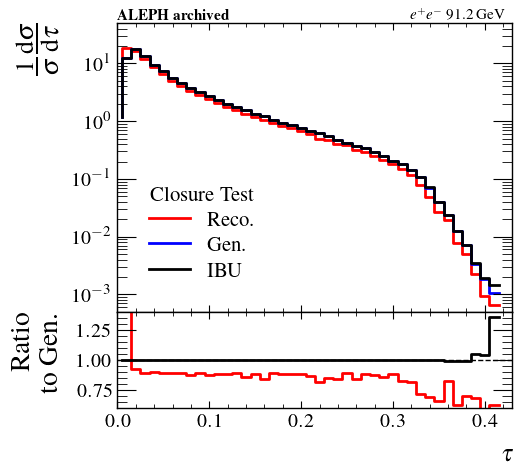

In [277]:
# closure check
fig, axs = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]},  # top panel taller, bottom three equal
    figsize=[5,5]
)
plt.subplots_adjust(hspace=0)

# hists
axs[0].step(x, w["ClosureTest"]["reco"], label="Reco.", color="red")
axs[0].step(x, w["ClosureTest"]["gen"], label="Gen.", color="blue")
axs[0].step(x, w["ClosureTest"]["nominal"], label="IBU", color="black")

# header
axs[0].text(0, 1.0, r"$\textbf{ALEPH\ archived}$", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=11)
axs[0].text(0.74, 1.0, r"$e^{+}e^{-}$ 91.2 GeV", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=11)

# labels
axs[0].set_ylabel(r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\tau}}$", fontsize=25)
axs[0].set_yscale("log")
axs[0].set_ylim(5*10**-4, 5*10**1)

# ratios
axs[1].step(x, w["ClosureTest"]["reco"]/w["ClosureTest"]["gen"], color="red")
axs[1].step(x, w["ClosureTest"]["nominal"]/w["ClosureTest"]["gen"], color="black")

axs[1].axhline(y=1, color='black', linestyle='--', alpha=1, lw=1)
axs[1].set_ylim(0.6, 1.4)
axs[1].set_xlim(0, 0.43)
axs[1].set_xlabel(r"$\tau$")
axs[1].set_ylabel("Ratio\nto Gen.", fontsize=20)

axs[0].legend(ncol=1, fontsize=15, title="Closure Test", title_fontsize=15)

plt.show()

In [278]:
# statistical uncertainty
total_stat = np.sqrt(
    w["BootstrapMC"]["nominal"]**2 +
    w["BootstrapData"]["nominal"]**2
)

In [279]:
# experimental systematic 
exp_syst_names = []
exp_syst = []
for key, val in w["Systematics"].items():
    exp_syst_names.append(key)
    exp_syst.append(w["Nominal"]["nominal"] - val)
exp_syst = np.stack(exp_syst)
print(exp_syst.shape)
total_exp_syst = np.sqrt(np.sum(exp_syst**2, axis=0))
print(total_exp_syst.shape)

(6, 42)
(42,)


In [280]:
# theoretical uncertainty
th_syst_names = ["Pythia8", "Herwig", "Sherpa"]
th_syst = []
for key in th_syst_names:
    th_syst.append(w["Nominal"]["nominal"] - w[f"TheoryUncertainty_{key}"]["nominal"])
th_syst = np.stack(th_syst)
print(th_syst.shape)
# total_th_syst = np.sqrt(np.sum(th_syst**2, axis=0))
total_th_syst = np.max(np.abs(th_syst), axis=0)
print(total_th_syst.shape)

(3, 42)
(42,)


In [281]:
total_uncert = np.sqrt(
    total_stat**2 + 
    total_exp_syst**2 + 
    total_th_syst **2
)
print(total_uncert.shape)

(42,)


Reminder since divide by nominal we don't need to scale by hadronic event selection.


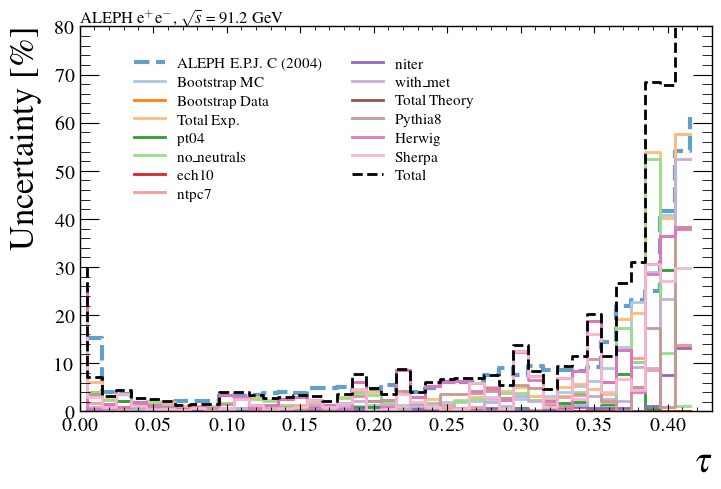

In [282]:
print("Reminder since divide by nominal we don't need to scale by hadronic event selection.")

# plot uncertainty breakdown
fig, ax = plt.subplots(figsize=(8, 5))
# Use a color cycle from matplotlib that doesn't repeat for the number of error components
colors = plt.cm.tab20.colors  # 20 unique colors
color_cycle = itertools.cycle(colors)

# draw aleph
ax.step(aleph["aleph_midbins"], aleph["aleph_thrust_errs"] / aleph["aleph_thrust"] * 100, where='post', label="ALEPH E.P.J. C (2004)", color=next(color_cycle), linestyle="--", lw=3, alpha=0.7)

# draw MC stat
ax.step(x, w["BootstrapMC"]["nominal"]/w["Nominal"]["nominal"]*100, label="Bootstrap MC", color=next(color_cycle))
ax.step(x, w["BootstrapData"]["nominal"]/w["Nominal"]["nominal"]*100, label="Bootstrap Data", color=next(color_cycle))

# draw experimental
ax.step(x, total_exp_syst/w["Nominal"]["nominal"]*100, label="Total Exp.", color=next(color_cycle))
for name, unc in zip(exp_syst_names, exp_syst):
    ax.step(x, np.abs(unc)/w["Nominal"]["nominal"]*100, label=name, color=next(color_cycle))
    
# draw theory
ax.step(x, total_th_syst/w["Nominal"]["nominal"]*100, label="Total Theory", color=next(color_cycle))
for name, unc in zip(th_syst_names, th_syst):
    ax.step(x, np.abs(unc)/w["Nominal"]["nominal"]*100, label=name, color=next(color_cycle))
    
# draw total
ax.step(x, total_uncert/w["Nominal"]["nominal"]*100, label="Total", color="Black", ls="--")

ax.text(0, 1, r"ALEPH e$^{+}$e$^{-}$, $\sqrt{s}$ = 91.2 GeV", transform=ax.transAxes, ha='left', va='bottom', fontsize=12)

ax.set_ylim(0, 80)
# ax.set_yscale("log")
# ax.set_ylim(5*10**-3, 2*10**3)
ax.set_xlim(0, 0.43)
ax.set_ylabel(r"Uncertainty [$\%$]", fontsize=25)
ax.set_xlabel(r"$\tau$", fontsize=25)

ax.legend(ncol=2, fontsize=11, bbox_to_anchor=(0.05, 0.98), loc="upper left")

plt.show()

In [283]:
outFileName = os.path.join(top_dir, "ibu_results.npz")
print(outFileName)
np.savez(
    outFileName,
    # nominal result
    nominal = w["Nominal"]["nominal"],
    # statistical uncertainty components
    total_stat = total_stat,
    bootstrapmc = w["BootstrapMC"]["nominal"],
    bootstrapdata = w["BootstrapData"]["nominal"],
    # experimental systematic
    exp_syst_names = exp_syst_names,
    exp_syst = exp_syst,
    total_exp_syst = total_exp_syst,
    # theory uncertainty from MC prior
    th_syst_names = th_syst_names,
    th_syst = th_syst,
    total_th_syst = total_th_syst,
    # total error from quadrature sum of mcstat, total exp syst, total theory syst
    total_uncert = total_uncert,
)

/home/badea/e+e-/aleph/unfold-ee-logtau/ibu_results/training-825bab2d/ibu_results.npz


In [284]:
d = {}
with np.load(outFileName) as data:
    for k in data.keys():
        v = data[k]
        # If it's an object array whose first element is a str, treat it as a text list
        if v.dtype == object and len(v) > 0 and isinstance(v[0], str):
            print(f"{k}: text list -> {v.tolist()}")
        else:
            print(f"{k}: numpy array, shape {v.shape}, dtype {v.dtype}")
        # store 
        d[k] = v

nominal: numpy array, shape (42,), dtype float64
total_stat: numpy array, shape (42,), dtype float64
bootstrapmc: numpy array, shape (42,), dtype float64
bootstrapdata: numpy array, shape (42,), dtype float64
exp_syst_names: numpy array, shape (6,), dtype <U11
exp_syst: numpy array, shape (6, 42), dtype float64
total_exp_syst: numpy array, shape (42,), dtype float64
th_syst_names: numpy array, shape (3,), dtype <U7
th_syst: numpy array, shape (3, 42), dtype float64
total_th_syst: numpy array, shape (42,), dtype float64
total_uncert: numpy array, shape (42,), dtype float64


In [285]:
print(d["exp_syst_names"])
print(d["exp_syst"].shape)
print(total_exp_syst)

['pt04' 'no_neutrals' 'ech10' 'ntpc7' 'niter' 'with_met']
(6, 42)
[0.16997386 0.7395453  0.48729862 0.31044951 0.1821338  0.16116527
 0.11169255 0.04933432 0.04030432 0.03704055 0.04780984 0.06092551
 0.05789977 0.04005931 0.01950988 0.01691121 0.02105191 0.01201356
 0.02599359 0.0350453  0.02834729 0.01486646 0.00403245 0.00953138
 0.01192551 0.006447   0.00811363 0.00886166 0.01300074 0.00923555
 0.00956803 0.00537917 0.00344718 0.00555142 0.00424239 0.00205197
 0.00090965 0.00258426 0.00171085 0.0026831  0.00142567 0.00159742]


[2.53336810e-13 1.90864678e-13 1.76335703e-13 1.43227294e-13
 2.38377507e-13 7.24069130e-14 1.53630655e-14 1.32135248e-13
 2.29602610e-13 1.78874219e-13 6.55645366e-14 7.78220553e-14
 1.02897327e-13 1.43662000e-13 2.97109244e-14 2.71195013e-13
 9.38087028e-14 1.53548508e-13 1.26322166e-13 2.43594058e-13
 8.06200460e-14 1.57821310e-13 2.70425474e-13 4.31307894e-14
 2.31798715e-13 5.59056306e-14 3.30099179e-14 1.82543108e-13
 1.51438853e-13 1.49859626e-13 2.83633973e-13 2.34283943e-13
 2.02009221e-14 1.51424184e-13 1.70387634e-13 1.44456361e-13
 9.93733531e-14 1.41155949e-13 8.28915598e-14 3.48359070e-14
 1.71619565e-13 1.09446653e-13]
[ 1.21175766  0.26783653  0.2290592   0.29526489  0.39162436  0.39845342
  0.4590992   0.49401611  0.59995863  0.61352169  0.65683318  0.77256695
  0.85000221  0.86154192  0.87828189  1.02312913  1.14761298  1.21114483
  1.1567021   1.19245148  1.40501332  1.49704735  1.38612353  1.64307305
  1.8041639   1.97082262  1.9039924   2.20275835  2.61802062  2.36

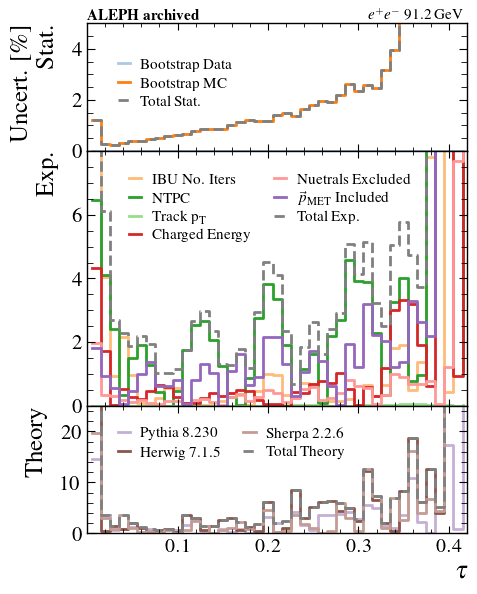

In [289]:
import itertools

# Enable LaTeX text rendering
plt.rcParams.update({
    "text.usetex": True,          # use LaTeX for all text
    "font.family": "serif",       # optional: use serif font
    "font.size": 12               # default font size
})

# global style
style = {
    "legend_loc" : None,
    "legend_bbox" : None,
    "legend_ncol" : 1,
    "legend_fontsize" : 13,
    "ax1_ylabel_fs" : 22,
    "ax2_xlabel_fs" : 18,
    "ax2_ylabel_fs" : 16,
    "ax1_tick_ls" : 16,
    "ax2_tick_ls" : 16,
    "figsize" : (5,6), 
    "header_fontsize" : 11,
    "ax1_xlim" : [0, 0.42],
    "ax1_ylim" : [2*10**-3, 7*10**-1],
    "ax1_ylabel" : "Uncertainty [$\%$]",
    "ax1_xlabel" : r"$\tau$",
    "legend_bbox" : (0.45, 0.05),  
}

# labels for individual components
statLabels = {
    "bootstrapdata" : "Bootstrap Data",
    "bootstrapmc" : "Bootstrap MC"
}
expLabels = {
    "ntpc7" : "NTPC",
    "pt04": r"Track p$_{\mathrm{T}}$",
    "ech10" : "Charged Energy",
    "no_neutrals" : "Nuetrals Excluded",
    "with_met" : r"$\vec{p}_{\mathrm{MET}}$ Included",
    "niter" : "IBU No. Iters"
}
theoryLabels = {
    "Pythia8" : "Pythia 8.230",
    "Herwig" : "Herwig 7.1.5", 
    "Sherpa" : "Sherpa 2.2.6",
}

fontsize = 18

colors = plt.cm.tab20.colors  # 20 unique colors
color_cycle = itertools.cycle(colors)  # restartable iterator

# plotting
fig, axs = plt.subplots(
    3, 1,
    sharex=True,
    gridspec_kw={'height_ratios': [1,2,1]},  # top panel taller, bottom three equal
    figsize=style["figsize"]
)
plt.subplots_adjust(hspace=0)


# header
axs[0].text(0, 1.0, r"$\textbf{ALEPH\ archived}$", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=style["header_fontsize"])
axs[0].text(0.74, 1.0, r"$e^{+}e^{-}$ 91.2 GeV", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=style["header_fontsize"])

next(color_cycle)

# statistical
ax = axs[0]
ax.set_ylim(0, 5)
stat_oder = ["bootstrapdata", "bootstrapmc"]
for i, label in enumerate(stat_oder):
    print(np.abs(d[label])/d["nominal"]*100)
    ax.step(x, np.abs(d[label])/d["nominal"]*100, where='post', label=statLabels[label], color=next(color_cycle), ls="-")
ax.step(x, d["total_stat"]/d["nominal"]*100, where='post', label="Total Stat.", color="gray", ls="--")

ax.legend(
    ncol=1, fontsize=11, bbox_to_anchor=(0.02, 0.15), loc="lower left",
    handletextpad=0.7,
    handlelength=0.8, 
    columnspacing=0.6
)

# experimental
ax = axs[1]
ax.set_ylim(0, 8)
ax.set_yticks([0,2,4,6])
exp_order = ['niter', 'ntpc7', 'pt04', 'ech10', "no_neutrals", 'with_met']
for i, label in enumerate(exp_order):
    ax.step(x, np.abs(d["exp_syst"][i])/d["nominal"]*100, where='post', label=expLabels[label], color=next(color_cycle), ls="-")
ax.step(x, d["total_exp_syst"]/d["nominal"]*100, where='post', label="Total Exp.", color="gray", ls="--")
ax.legend(
    ncol=2, fontsize=11, bbox_to_anchor=(0.05, 0.55), loc="lower left",
    handletextpad=0.7,
    handlelength=0.8, 
    columnspacing=1.5
)

# theory
ax = axs[2]
ax.set_ylim(0, 25)
for i, label in enumerate(d["th_syst_names"]):
    ax.step(x, np.abs(d["th_syst"][i])/d["nominal"]*100, where='post', label=theoryLabels[label], color=next(color_cycle), ls="-")
ax.step(x, d["total_th_syst"]/d["nominal"]*100, where='post', label="Total Theory", color="gray", ls="--")
ax.legend(
    ncol=2, fontsize=11, bbox_to_anchor=(0.02, 0.4), loc="lower left",
    handletextpad=0.7,
    handlelength=0.8, 
    columnspacing=1.5
)


axs[0].set_xlim(style["ax1_xlim"][0], style["ax1_xlim"][1])
axs[0].set_xticks([0.1,0.2,0.3,0.4])

# ax1 settings
for ax, name in zip(axs, ["Uncert. [$\%$]\nStat.", "Exp.", "Theory"]): # "MC Prior"
    ax.set_ylabel(name, fontsize=18)
    
# set final x-axis
axs[-1].set_xlabel(style["ax1_xlabel"], fontsize=style.get("ax2_xlabel_fs", 18), labelpad=4)
    
# tick length
for ax in axs:
    ax.tick_params(axis="y", which="major", length=6)
    ax.tick_params(axis="y", which="minor", length=4)
    ax.tick_params(axis="x", which="major", length=5)
    ax.tick_params(axis="x", which="minor", length=3)

# tick size
# axs[0].tick_params(axis='y', labelsize=16)
for ax in axs:
    ax.tick_params(axis='y', labelsize=15)
    


fig.set_size_inches(style["figsize"][0], style["figsize"][1])  
fig.subplots_adjust(left=0.18, right=0.94, top=0.95, bottom=0.1)

plotOutDir = "ibuResult"
plt.savefig(f"{plotOutDir}/tau_ibu_aleph_uncertainty.pdf", bbox_inches=None, dpi=150)
plt.show()
plt.close()